# Week 5 — Part 1: NLP Techniques & Sentiment Classification
### Amazon Product Reviews — Sentiment Analysis

This notebook implements the complete NLP pipeline for classifying Amazon customer reviews as positive or negative, including data inspection, text cleaning, word cloud visualization, feature extraction, model training, evaluation, and model selection.


In [1]:
!pip install wordcloud -q


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import re
import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

## Step 1: Load Dataset and Inspect Review Text and Label Columns

The dataset is loaded, its structure is inspected, and the class distribution of sentiment labels is checked to understand the balance between positive and negative reviews.


In [5]:
from pathlib import Path
import pandas as pd
DATA_PATH = Path("../Data/amazon_reviews.csv")
assert DATA_PATH.exists()

df_raw = pd.read_csv(DATA_PATH)
df_raw.shape

(3150, 5)

In [6]:
df_raw.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [7]:
review_col = "verified_reviews" if "verified_reviews" in df_raw.columns else next(
    (c for c in df_raw.columns if "review" in c.lower()), None
)
label_col = "feedback" if "feedback" in df_raw.columns else next(
    (c for c in df_raw.columns if "label" in c.lower() or "sentiment" in c.lower()), None
)
review_col, label_col

('verified_reviews', 'feedback')

In [8]:
df = df_raw[[review_col, label_col]].copy()
df.columns = ["verified_reviews", "feedback"]
df = df.dropna(subset=["verified_reviews", "feedback"])

if df["feedback"].dtype == object:
    df["feedback"] = df["feedback"].str.lower().map({"positive": 1, "negative": 0, "1": 1, "0": 0})
df["feedback"] = df["feedback"].astype(int)

df["sentiment"] = df["feedback"].map({1: "positive", 0: "negative"})
df = df[df["sentiment"].notna()].reset_index(drop=True)
df.shape

(3149, 3)

In [9]:
df["sentiment"].value_counts()

sentiment
positive    2893
negative     256
Name: count, dtype: int64

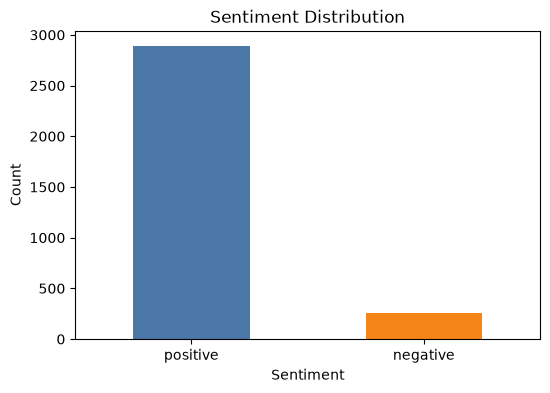

In [11]:
import matplotlib.pyplot as plt
counts = df["sentiment"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_title("Sentiment Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Sentiment")
plt.xticks(rotation=0)
plt.show()

## Step 2: Clean the Raw Text

The raw review text is cleaned to remove noise and reduce dimensionality before vectorization. The cleaning pipeline performs the following operations:

- Converts all text to lowercase
- Removes URLs and HTML tags
- Removes punctuation and numeric characters, keeping only alphabetic tokens
- Removes common stopwords and generic filler words that carry little sentiment-specific meaning
- Drops single-character tokens


In [13]:
import re
import pandas as pd
STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "been", "being", "but", "by", "for", "from",
    "had", "has", "have", "i", "in", "is", "it", "its", "just", "me", "my", "not", "of", "on",
    "or", "our", "so", "that", "the", "their", "this", "to", "was", "were", "what", "when",
    "where", "which", "who", "will", "with", "would", "you", "your", "very", "really", "can",
    "could", "love", "loved", "good", "great"
}

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [token for token in text.split() if token not in STOPWORDS and len(token) > 1]
    return " ".join(tokens)

df["cleaned_review"] = df["verified_reviews"].apply(clean_text)
df[["verified_reviews", "cleaned_review"]].head()

,verified_reviews,cleaned_review
0,Love my Echo!,echo
1,Loved it!,
2,"Sometimes while playing a game, you can answer...",sometimes while playing game answer question c...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns about dinosaurs co...
4,Music,music


## Step 3: Generate Word Clouds for Positive and Negative Reviews

Two separate word clouds are generated from the cleaned text — one for positive reviews and one for negative reviews — to visually compare the most frequent terms associated with each sentiment class.


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
def create_wordcloud(texts, title):
    text = " ".join(texts.astype(str))
    wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return wc

positive_reviews = df.loc[df["feedback"] == 1, "cleaned_review"]
negative_reviews = df.loc[df["feedback"] == 0, "cleaned_review"]

pos_wc = create_wordcloud(positive_reviews, "Positive Reviews Word Cloud")

NameError: name 'df' is not defined

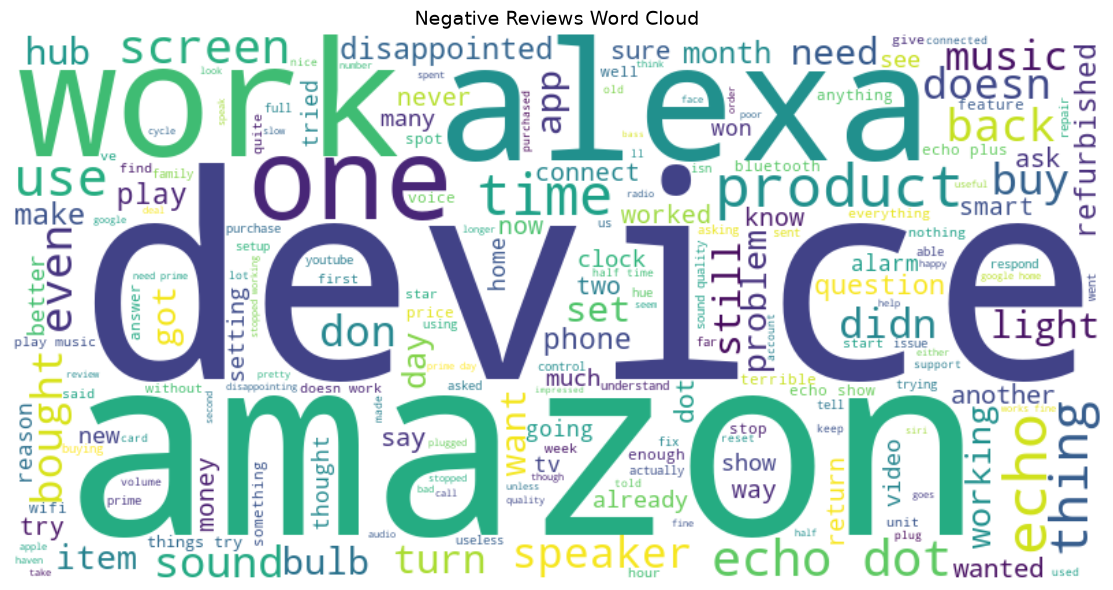

In [17]:
neg_wc = create_wordcloud(negative_reviews, "Negative Reviews Word Cloud")

In [18]:
Path("models").mkdir(exist_ok=True)
pos_wc.to_file("models/positive_reviews_wordcloud.png")
neg_wc.to_file("models/negative_reviews_wordcloud.png")

## Step 4: Convert Cleaned Text into Numerical Features

**Vectorization technique chosen: TF-IDF (Term Frequency–Inverse Document Frequency)**

TF-IDF was selected over a simple Bag-of-Words representation because it down-weights words that occur frequently across the entire corpus (and therefore carry little discriminative value) while up-weighting terms that are more specific to individual reviews. This produces more informative features for classical machine learning classifiers such as Logistic Regression and Naive Bayes, without the computational overhead of dense embedding-based approaches. An n-gram range of (1, 2) is used so that both individual words and two-word phrases (e.g. "not good") are captured, which is particularly useful for sentiment-bearing expressions.


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

## Step 5: Split Data and Train Classification Models

The dataset is split into training and testing sets using an 80/20 ratio with stratification to preserve class balance. Two classification models are trained: **Logistic Regression** and **Multinomial Naive Bayes**, both widely used and effective baselines for text classification tasks.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_review"], df["feedback"], test_size=0.2, random_state=42, stratify=df["feedback"]
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape

((2519, 5000), (630, 5000))

In [23]:
models = {
    "logistic_regression": LogisticRegression(max_iter=3000, random_state=42),
    "multinomial_nb": MultinomialNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    results[name] = {
        "model": model,
        "predictions": preds,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "report": classification_report(y_test, preds, target_names=["negative", "positive"], output_dict=True),
        "cm": confusion_matrix(y_test, preds),
    }

c:\Users\Kiran\Desktop\ITSimplera_Institute\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kiran\Desktop\ITSimplera_Institute\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kiran\Desktop\ITSimplera_Institute\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

## Step 6: Evaluate Models and Visualize Confusion Matrices

Each model is evaluated using accuracy, precision, recall, and F1-score, and a confusion matrix is plotted for each model to visualize classification performance across both sentiment classes.


In [24]:
for name, res in results.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, res["predictions"], target_names=["negative", "positive"]))

--- logistic_regression ---
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        51
    positive       0.92      1.00      0.96       579

    accuracy                           0.92       630
   macro avg       0.46      0.50      0.48       630
weighted avg       0.84      0.92      0.88       630

--- multinomial_nb ---
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        51
    positive       0.92      1.00      0.96       579

    accuracy                           0.92       630
   macro avg       0.46      0.50      0.48       630
weighted avg       0.84      0.92      0.88       630



c:\Users\Kiran\Desktop\ITSimplera_Institute\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kiran\Desktop\ITSimplera_Institute\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kiran\Desktop\ITSimplera_Institute\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

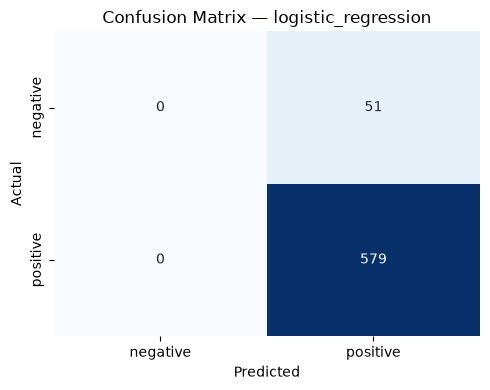

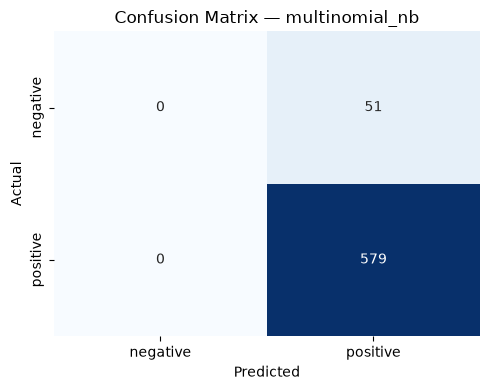

In [25]:
for name, res in results.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(res["cm"], annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## Step 7: Compare Model Performance and Save the Best Model

Model performance is compared across all evaluation metrics in a single chart. The best-performing model, selected based on F1-score, is saved along with its TF-IDF vectorizer for use in the Part 2 Streamlit dashboard.


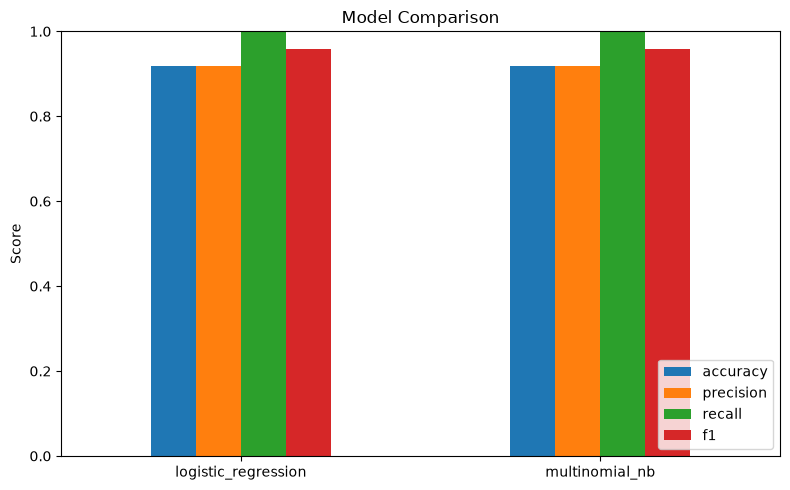

,accuracy,precision,recall,f1
logistic_regression,0.919048,0.919048,1.0,0.957816
multinomial_nb,0.919048,0.919048,1.0,0.957816


In [26]:
comparison_df = pd.DataFrame({
    name: {
        "accuracy": res["accuracy"],
        "precision": res["precision"],
        "recall": res["recall"],
        "f1": res["f1"],
    }
    for name, res in results.items()
}).T

comparison_df.plot(kind="bar", figsize=(8, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

comparison_df

In [27]:
best_name = max(results, key=lambda name: results[name]["f1"])
best_model = results[best_name]["model"]
best_name, results[best_name]["f1"]

('logistic_regression', 0.9578163771712159)

In [28]:
joblib.dump(vectorizer, "models/tfidf_vectorizer.joblib")
joblib.dump(best_model, "models/best_model.joblib")

['models/best_model.joblib']